# Likelihood toys — moment predictions without threshold

Histograms of the moments predicted by the toys drawn from the likelihood of the nominal
O(1/mb³) fit (`python -m kolya_fit.likelihood_toys`, see `kolya_fit/likelihood_toys.py`).
Only the cut-free moments are shown (`q2_n_cut0.0`, `mx_n_cut0.0`, `el_n_cut0.0`).

Per panel: the toy distribution, the best-fit prediction (solid), the toy median (dashed) and
the central 68.27% interval (shaded), which is the quoted uncertainty.  The thin curve is a
Gaussian with the best-fit mean and the toy standard deviation, as a reference for the
non-Gaussianity.

In [1]:
import os

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt


def band(sample):
    """Half the width of the central 68.27% interval of the toys, plus the interval itself."""
    x = np.asarray(sample, dtype=float)
    x = x[np.isfinite(x)]
    low, high = np.percentile(x, [15.865, 84.135])
    return {"half": 0.5 * (high - low), "low": low, "high": high,
            "std": x.std(ddof=1), "n": x.size}

In [2]:
outputdir = "moments"
os.makedirs(os.path.join(outputdir, "figures"), exist_ok=True)

SAVE_FIGURES = True

def save_figure(fig, name):
    if SAVE_FIGURES:
        fig.savefig(os.path.join(outputdir, "figures", f"likelihood_toys_{name}.pdf"), bbox_inches="tight")

In [3]:
# likelihood_toys.h5 next to this notebook (in the repo: ../kolya_fit/moments/NLOpw_1_NNLO_1_mb3_default/full/)
fitdir = "."
toys = pd.read_hdf(os.path.join(fitdir, "likelihood_toys.h5"), "toys")
central = pd.read_hdf(os.path.join(fitdir, "likelihood_toys.h5"), "central").iloc[0]
print(f"{len(toys)} toys")

12000 toys


## Cut-free moments

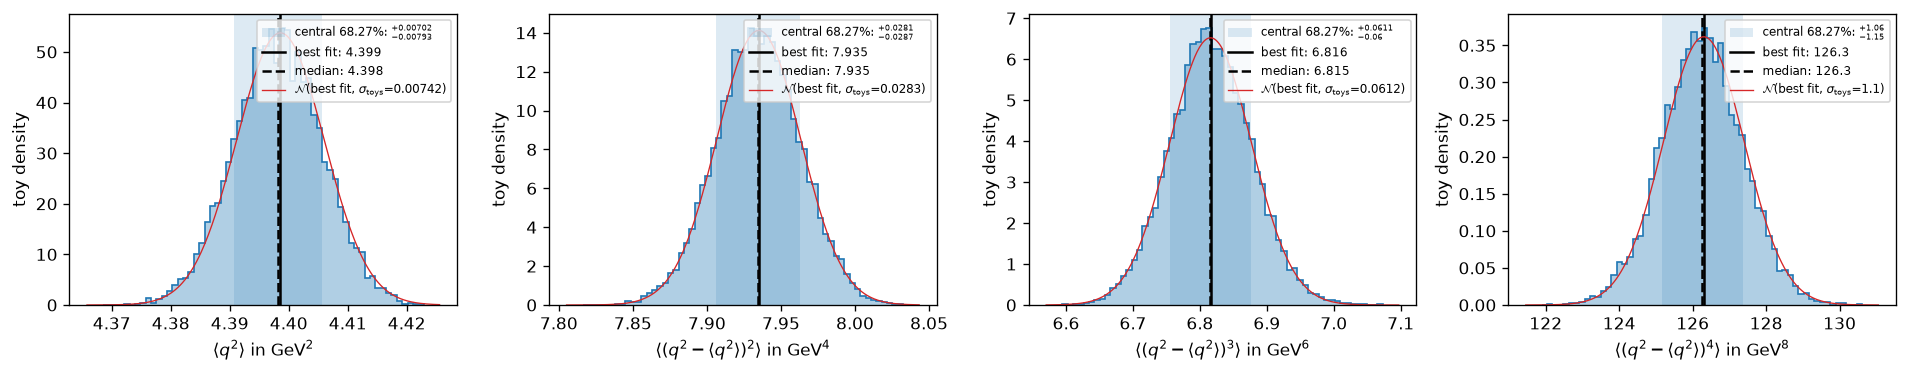

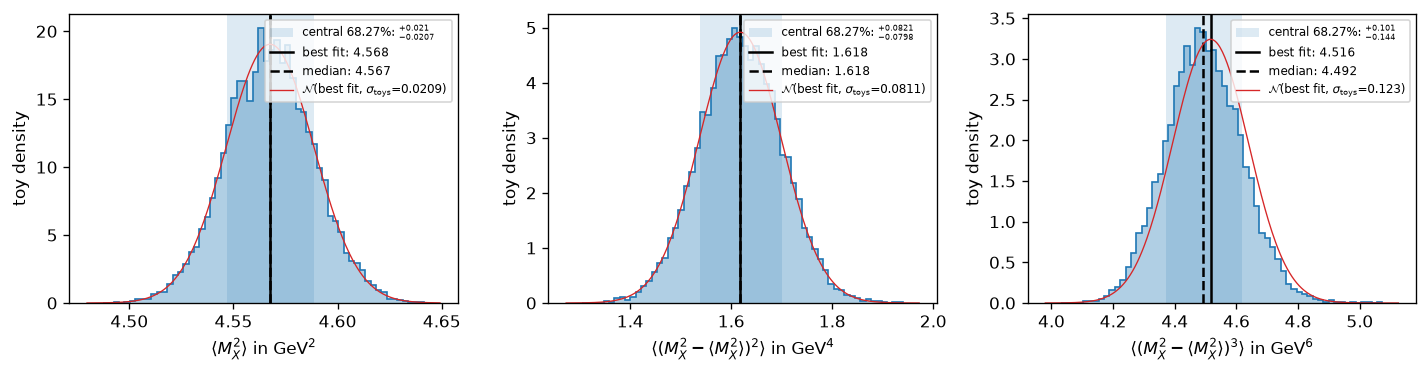

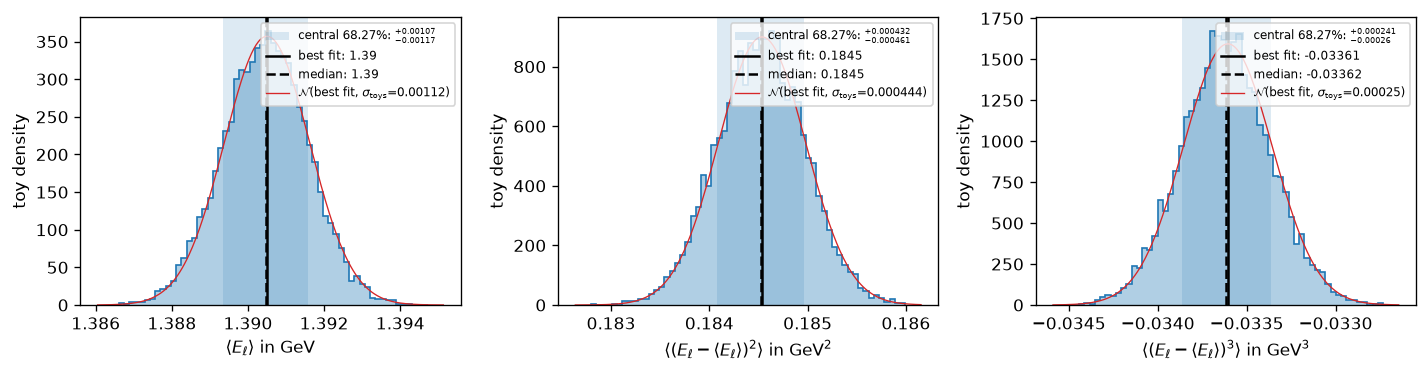

In [4]:
# variable -> (moment orders, panel label, unit)
MOMENTS = {
    "q2": ([1, 2, 3, 4], lambda n: r"$\langle q^2 \rangle$" if n == 1
           else rf"$\langle (q^2 - \langle q^2 \rangle)^{n} \rangle$", lambda n: rf"$\mathrm{{GeV}}^{{{2 * n}}}$"),
    "mx": ([1, 2, 3], lambda n: r"$\langle M_X^2 \rangle$" if n == 1
           else rf"$\langle (M_X^2 - \langle M_X^2 \rangle)^{n} \rangle$", lambda n: rf"$\mathrm{{GeV}}^{{{2 * n}}}$"),
    "el": ([1, 2, 3], lambda n: r"$\langle E_\ell \rangle$" if n == 1
           else rf"$\langle (E_\ell - \langle E_\ell \rangle)^{n} \rangle$",
           lambda n: r"$\mathrm{GeV}$" if n == 1 else rf"$\mathrm{{GeV}}^{{{n}}}$"),
}


def plot_histogram(ax, column, label, unit):
    x = toys[column].to_numpy()
    x0 = central[column]
    b = band(x)
    ax.hist(x, bins=60, density=True, histtype="stepfilled", alpha=0.35, color="C0")
    ax.hist(x, bins=60, density=True, histtype="step", color="C0")
    ax.axvspan(b["low"], b["high"], color="C0", alpha=0.15, lw=0,
               label=rf"central 68.27%: $^{{+{b['high'] - x0:.3g}}}_{{-{x0 - b['low']:.3g}}}$")
    ax.axvline(x0, color="k", label=f"best fit: {x0:.4g}")
    ax.axvline(np.median(x), color="k", ls="--", label=f"median: {np.median(x):.4g}")
    grid = np.linspace(*ax.get_xlim(), 300)
    ax.plot(grid, scipy.stats.norm.pdf(grid, x0, b["std"]), color="C3", lw=0.8,
            label=rf"$\mathcal{{N}}$(best fit, $\sigma_\mathrm{{toys}}$={b['std']:.3g})")
    ax.set_xlabel(f"{label} in {unit}")
    ax.set_ylabel("toy density")
    ax.legend(fontsize=7, loc="upper right")


for variable, (orders, label, unit) in MOMENTS.items():
    fig, axes = plt.subplots(1, len(orders), figsize=(4 * len(orders), 3.2), dpi=120)
    for ax, n in zip(axes, orders):
        plot_histogram(ax, f"{variable}_{n}_cut0.0", label(n), unit(n))
    fig.tight_layout()
    save_figure(fig, variable)
    plt.show()